In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df = pd.read_csv("dataset/crypto50_combined.csv")
df.head()

,date,price,market_cap,volume,cryptocurrency,symbol,percent_change_24h
0,2013-04-29 23:59:59,134.44400,1.603769e+09,0.0,Bitcoin,BTC,NaN
1,2013-04-29 23:59:59,4.36676,7.538896e+07,0.0,Litecoin,LTC,NaN
2,2013-04-30 23:59:59,4.40352,7.402092e+07,0.0,Litecoin,LTC,0.841822
3,2013-04-30 23:59:59,144.00000,1.542813e+09,0.0,Bitcoin,BTC,7.107792
4,2013-05-01 23:59:59,139.00000,1.298955e+09,0.0,Bitcoin,BTC,-3.472222


In [3]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19853 entries, 0 to 19852
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                19853 non-null  datetime64[ns]
 1   price               19853 non-null  float64       
 2   market_cap          19853 non-null  float64       
 3   volume              19853 non-null  float64       
 4   cryptocurrency      19853 non-null  object        
 5   symbol              19853 non-null  object        
 6   percent_change_24h  19843 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 1.1+ MB


In [4]:
df.isnull().sum()

date                   0
price                  0
market_cap             0
volume                 0
cryptocurrency         0
symbol                 0
percent_change_24h    10
dtype: int64

In [5]:
df.describe()


,date,price,market_cap,volume,percent_change_24h
count,19853,19853.000000,1.985300e+04,1.985300e+04,19843.000000
mean,2018-02-18 08:06:36.481488896,1059.537259,2.612996e+10,3.027239e+09,0.495836
min,2013-04-29 23:59:59,0.000087,0.000000e+00,0.000000e+00,-74.724530
25%,2016-04-30 23:59:59,0.021310,1.953898e+08,2.554360e+06,-2.391111
50%,2018-05-19 23:59:59,0.795761,1.950045e+09,8.251476e+07,-0.038200
75%,2020-01-30 23:59:59,91.649834,1.140139e+10,1.484851e+09,2.509059
max,2021-07-06 23:59:59,63523.754869,1.186364e+12,3.509679e+11,484.627724
std,NaN,4988.819678,9.492416e+10,9.280373e+09,8.227623


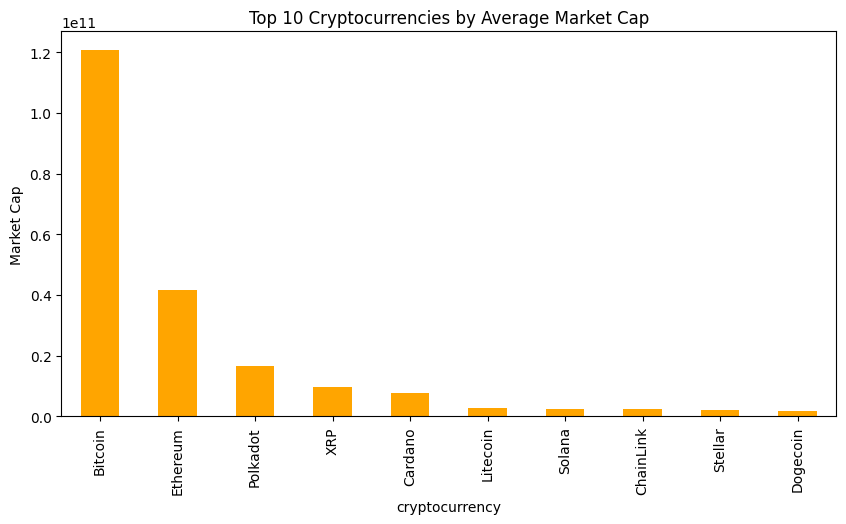

In [6]:
top_market = df.groupby('cryptocurrency')['market_cap'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_market.plot(kind='bar', color='orange')
plt.title("Top 10 Cryptocurrencies by Average Market Cap")
plt.ylabel("Market Cap")
plt.show()

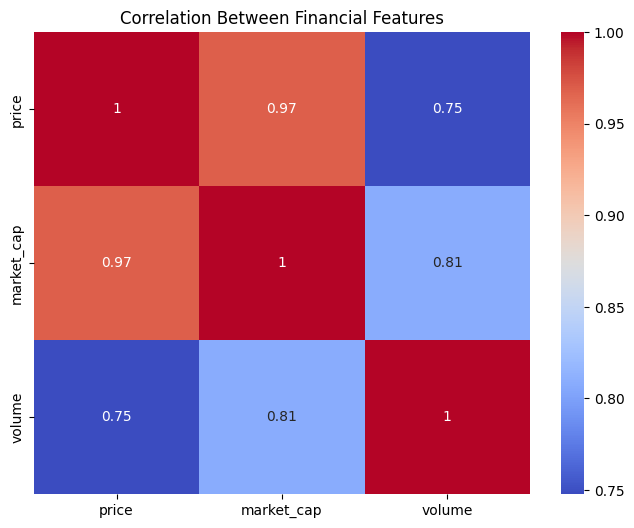

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['price','market_cap','volume']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Financial Features")
plt.show()

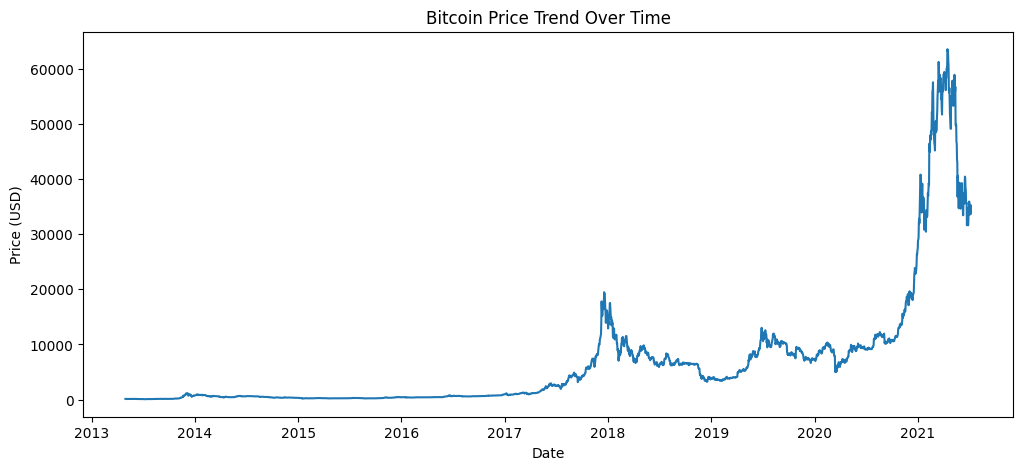

In [8]:
btc = df[df['cryptocurrency']=='Bitcoin']

plt.figure(figsize=(12,5))
plt.plot(btc['date'], btc['price'])
plt.title("Bitcoin Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

In [9]:
fig = px.line(df[df['cryptocurrency'].isin(['Bitcoin','Ethereum','Cardano','Litecoin'])],
              x='date', y='price', color='cryptocurrency',
              title="Multi Cryptocurrency Price Comparison")

fig.show()

In [10]:
btc = btc.sort_values('date')
btc['days'] = (btc['date'] - btc['date'].min()).dt.days

X = btc[['days']]
y = btc['price']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: -0.4387699822459512
MAE: 12810.859064369028
MSE: 437797094.1549923


In [14]:
import os
import joblib

os.makedirs("model", exist_ok=True)
joblib.dump(model, "model/model.pkl")

['model/model.pkl']

In [15]:
import sklearn
print(sklearn.__version__)

1.7.2
